## PREVISÃO DE SÉRIES TEMPORAIS MULTIVARIADAS COM PATCHTST
Projeto de análise e comparação da performance do modelo PatchTST na previsão de uma das 107 variáveis do dataset FRED-MD mediante treinamentos distintos.

Alunos: Anne Grazieli Marques Silva, Luiz Anselmo Medeiros Lima e Pedro Henrique Coelho Torres

In [ ]:
!pip install -q sktime
!pip install -q -U neuralforecast
!pip install -q "ray[tune]"

import site
from importlib import reload
reload(site)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.9/269.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 72.1 MB/s eta 0:00:00


<module 'site' (frozen)>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sktime.datasets import load_tsf_to_dataframe
from neuralforecast import NeuralForecast
from neuralforecast.auto import AutoPatchTST, PatchTST
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError, MeanAbsoluteError, MeanSquaredError
from neuralforecast.losses.pytorch import MAE, MSE, SMAPE
from sklearn.metrics import mean_absolute_error, mean_squared_error
from ray import tune

In [ ]:
# carrega o dataset, FRED MD
df, metadados = load_tsf_to_dataframe("fred_md_dataset.tsf")
df_transposto = df['series_value'].unstack(level=0)
# tipo dos dados = FLOAT
df_transposto = df_transposto.astype(float)
# define um dataframe com as variações percentuais entre os valores consecutivos
# das variaveis e remove as linhas NaN (sem valores)
df_diff = df_transposto.pct_change().dropna()

# variável target = T89
nome_target = 'T89'
y_target_series = df_diff[nome_target]
horizonte = 10

In [ ]:
def preparar_cenario_multivariado(df_base, target_col, exog_cols):
    cols = [target_col] + exog_cols
    df_f = df_base[cols].copy().reset_index()
    df_f.columns.values[0] = 'ds'
    df_f['ds'] = pd.to_datetime(df_f['ds'])
    # Transforma para o formato longo exigido pelo NeuralForecast
    df_long = df_f.melt(id_vars='ds', var_name='unique_id', value_name='y')
    return df_long

In [ ]:
# 5 variáveis selecionadas por nós
nomes_c1 = ['T83', 'T87', 'T62', 'T21', 'T68']

correlacao = df_diff.corrwith(y_target_series).abs().sort_values(ascending=False)
correlacao = correlacao.drop(nome_target)
# 5 variáveis mais correlacionadas com o target
nomes_c2 = correlacao.head(5).index.tolist()

first70var = []
for i in range(1, 70):
    first70var.append(f'T{i}')

# 70 primeiras variáveis do dataset
nomes_c3 = first70var


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


Dataframes que observaremos:
1) contendo as variáveis T83, T87, T62, T21, T68 que selecionamos;
2) contendo as variáveis T93, T96, T97, T98, T99 que tiveram maior correlação com a variável alvo (T87);
3) contendo as primeiras 70 primeiras variáveis do dataset.

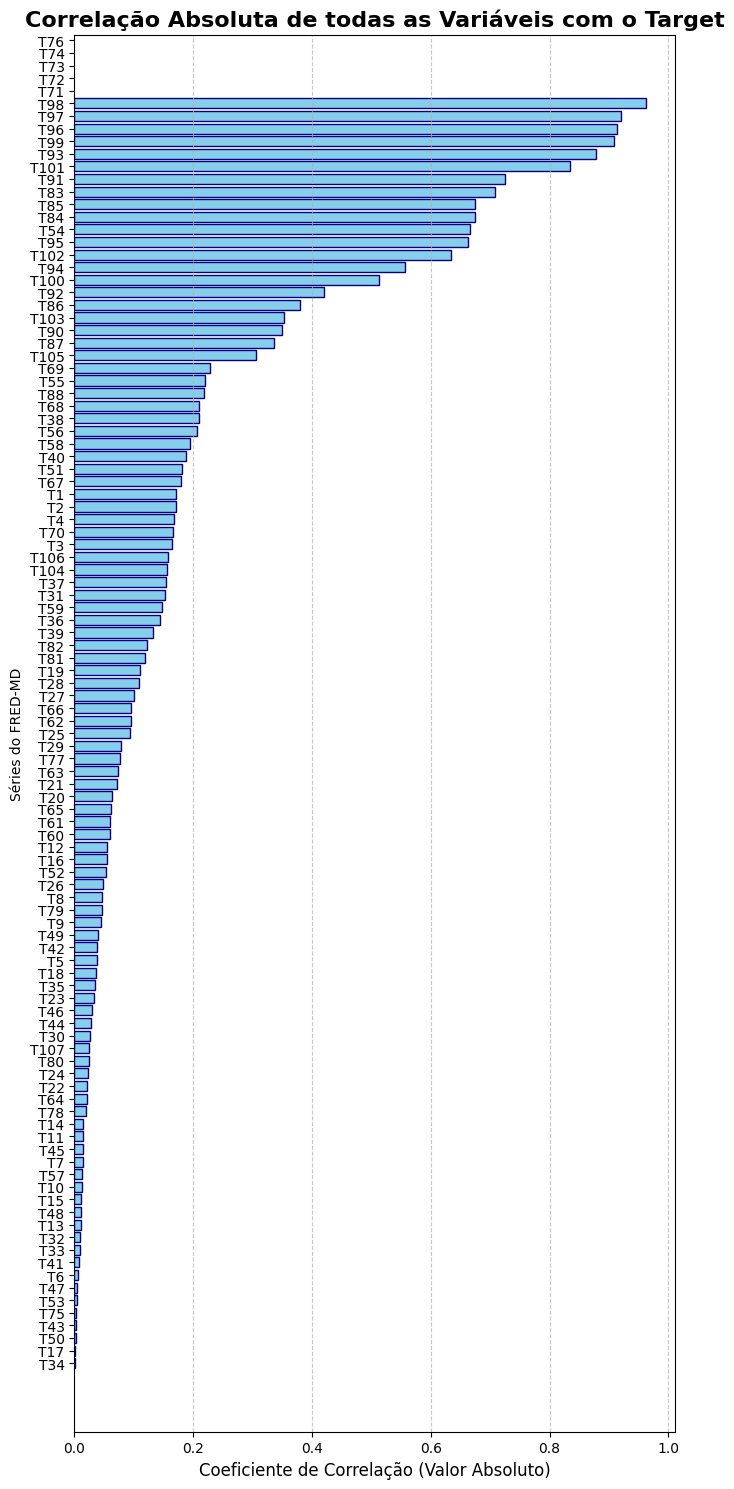

In [ ]:
plt.figure(figsize=(7, 15))
correlacao_ordenada = correlacao.sort_values(ascending=True)
plt.barh(correlacao_ordenada.index, correlacao_ordenada.values, color='skyblue', edgecolor='navy')
plt.title('Correlação Absoluta de todas as Variáveis com o Target', fontsize=16, fontweight='bold')
plt.xlabel('Coeficiente de Correlação (Valor Absoluto)', fontsize=12)
plt.ylabel('Séries do FRED-MD', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [ ]:
def modelo_otimizado():
    configs = {
        "max_steps": 1000,
        "revin": True,
        "patch_len": tune.choice([8, 12, 16]),
        "batch_size": tune.choice([64, 128]),
        "input_size": tune.choice([24, 48, 96]),
        "learning_rate": tune.choice([0.001, 0.0001]),
        "n_heads": tune.choice([8, 16]),
        "stride": tune.choice([8, 12, 16]),
        "encoder_layers": tune.choice([2, 3]),
        "dropout": tune.uniform(0.1, 0.3),
        "random_seed": 1,
        "scaler_type": "standard"
    }
    return AutoPatchTST(
        h=horizonte,
        loss=MAE(),
        valid_loss=MAE(),
        num_samples=10,
        config=configs
    )


In [ ]:
train_df_raw = df_diff.iloc[:715]
y_real = df_diff[nome_target].iloc[715:].values

# dataframe com os dados de treino do set 1 (5 variáveis que selecionamos)
df_c1_train = preparar_cenario_multivariado(train_df_raw, nome_target, nomes_c1)
# dataframe com os dados de treino do set 2 (5 variáveis mais correlacionadas)
df_c2_train = preparar_cenario_multivariado(train_df_raw, nome_target, nomes_c2)
# dataframe com os dados de treino do set 2 (70 variáveis)
df_c3_train = preparar_cenario_multivariado(train_df_raw, nome_target, nomes_c3)

In [ ]:
def evaluate_model(y_test, y_pred):
  mae = MeanAbsoluteError()
  maeV = mae(y_test, y_pred)
  mse = MeanSquaredError()
  mseV = mse(y_test, y_pred)
  rmse = mseV**0.5
  smape = MeanAbsolutePercentageError(symmetric=True)
  smapeV = smape(y_test, y_pred)
  return {"MAE": maeV, "RMSE": rmse, "SMAPE": smapeV}

In [ ]:
nf1 = NeuralForecast(models=[modelo_otimizado()], freq='MS')
nf1.fit(df=df_c1_train)

2026-01-31 11:47:44,620	INFO worker.py:2007 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
2026-01-31 11:47:57,286	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `Tuner(...)`.


+--------------------------------------------------------------------+
| Configuration for experiment     _train_tune_2026-01-31_11-47-35   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        FIFOScheduler                     |
| Number of trials                 10                                |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/_train_tune_2026-01-31_11-47-35
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-01-31_11-47-35_030789_1087/artifacts/2026-01-31_11-47-57/_train_tune_2026-01-31_11-47-35/driver_artifacts`


(pid=gcs_server) [2026-01-31 11:48:05,215 E 1505 1505] (gcs_server) gcs_server.cc:303: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(_train_tune pid=1855) /usr/local/lib/python3.12/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=1855) Seed set to 1
(_train_tune pid=1855) GPU available: True (cuda), used: True
(_train_tune pid=1855) TPU available: False, using: 0 TPU cores
(_train_tune pid=1855) 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
(_train_tune pid=1

(_train_tune pid=1855) ┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
(_train_tune pid=1855) ┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
(_train_tune pid=1855) ┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
(_train_tune pid=1855) │ 0 │ loss         │ MAE               │      0 │ train │     0 │
(_train_tune pid=1855) │ 1 │ valid_loss   │ MAE               │      0 │ train │     0 │
(_train_tune pid=1855) │ 2 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
(_train_tune pid=1855) │ 3 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
(_train_tune pid=1855) │ 4 │ model        │ PatchTST_backbone │  416 K │ train │     0 │
(_train_tune pid=1855) └───┴──────────────┴───────────────────┴────────┴───────┴───────┘
(_train_tune pid=1855) Trainable params: 416 K                                                         
(_train_tune pid=1855) Non-trainable params: 3                                                 

(_train_tune pid=1855) LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
(bundle_reservation_check_func pid=1652) [2026-01-31 11:48:26,154 E 1652 1722] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(_train_tune pid=1855) [2026-01-31 11:48:34,830 E 1855 1890] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14 [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(_train_tune pid=1855) `Trainer.fit` stopped: `max_steps=1000` reached.


...

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ eval  │     0 │
│ 1 │ valid_loss   │ MAE               │      0 │ eval  │     0 │
│ 2 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 3 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 4 │ model        │ PatchTST_backbone │  416 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 416 K                                                                                            
Non-trainable params: 3                                                                                            
Total params: 416 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 89                                                                                          
Modules in eval mode: 2                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

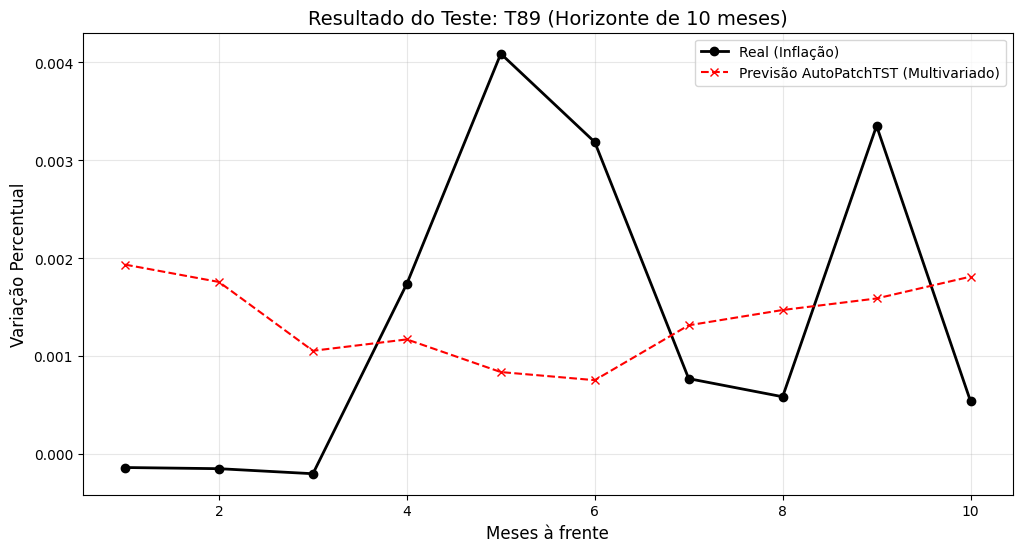

MAE Cenário 1: 0.0016


In [ ]:
preds = nf1.predict()
y_pred_c1 = preds.query(f"unique_id == '{nome_target}'")['AutoPatchTST'].values
y_real = df_diff[nome_target].iloc[715:].values


plt.figure(figsize=(12, 6))


eixo_x = range(1, horizonte + 1)

plt.plot(eixo_x, y_real, label='Real (Inflação)', color='black', marker='o', linewidth=2)
plt.plot(eixo_x, y_pred_c1, label='Previsão AutoPatchTST (Multivariado)', color='red', linestyle='--', marker='x')

plt.title(f'Resultado do Teste: {nome_target} (Horizonte de 10 meses)', fontsize=14)
plt.xlabel('Meses à frente', fontsize=12)
plt.ylabel('Variação Percentual', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
MAE1 = mean_absolute_error(y_real, y_pred_c1)

print(f"MAE Cenário 1: {mean_absolute_error(y_real, y_pred_c1):.4f}")

In [ ]:
nf2 = NeuralForecast(models=[modelo_otimizado()], freq='MS')
nf2.fit(df=df_c2_train)

+--------------------------------------------------------------------+
| Configuration for experiment     _train_tune_2026-01-31_11-56-09   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        FIFOScheduler                     |
| Number of trials                 10                                |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/_train_tune_2026-01-31_11-56-09
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-01-31_11-47-35_030789_1087/artifacts/2026-01-31_11-56-09/_train_tune_2026-01-31_11-56-09/driver_artifacts`


(_train_tune pid=4417) /usr/local/lib/python3.12/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=4417) Seed set to 1
(_train_tune pid=4417) GPU available: True (cuda), used: True
(_train_tune pid=4417) TPU available: False, using: 0 TPU cores
(_train_tune pid=4417) 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
(_train_tune pid=4417) 2026-01-31 11:56:22.148712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(_train_tune pid=4417) WARNING: All log messages before absl::InitializeLog() is ca

(_train_tune pid=4417) ┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
(_train_tune pid=4417) ┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
(_train_tune pid=4417) ┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
(_train_tune pid=4417) │ 0 │ loss         │ MAE               │      0 │ train │     0 │
(_train_tune pid=4417) │ 1 │ valid_loss   │ MAE               │      0 │ train │     0 │
(_train_tune pid=4417) │ 2 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
(_train_tune pid=4417) │ 3 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
(_train_tune pid=4417) │ 4 │ model        │ PatchTST_backbone │  416 K │ train │     0 │
(_train_tune pid=4417) └───┴──────────────┴───────────────────┴────────┴───────┴───────┘
(_train_tune pid=4417) Trainable params: 416 K                                                         
(_train_tune pid=4417) Non-trainable params: 3                                                 

(_train_tune pid=4417) [2026-01-31 11:56:42,563 E 4417 4450] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(_train_tune pid=4417) `Trainer.fit` stopped: `max_steps=1000` reached.


(_train_tune pid=4417) Epoch 999/-2 ━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s v_num: 0.000      
(_train_tune pid=4417)                                                               train_loss_step:  
(_train_tune pid=4417)                                                               0.499             
(_train_tune pid=4417)                                                               train_loss_epoch: 
(_train_tune pid=4417)                                                               0.499 valid_loss: 
(_train_tune pid=4417)                                                               0.002             


...


(_train_tune pid=6477) Epoch 999/-2 ━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s v_num: 0.000      
(_train_tune pid=6477)                                                               train_loss_step:  
(_train_tune pid=6477)                                                               0.466             
(_train_tune pid=6477)                                                               train_loss_epoch: 
(_train_tune pid=6477)                                                               0.466 valid_loss: 
(_train_tune pid=6477)                                                               0.002             


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ eval  │     0 │
│ 1 │ valid_loss   │ MAE               │      0 │ eval  │     0 │
│ 2 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 3 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 4 │ model        │ PatchTST_backbone │  406 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 406 K                                                                                            
Non-trainable params: 3                                                                                            
Total params: 406 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 89                                                                                          
Modules in eval mode: 2                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

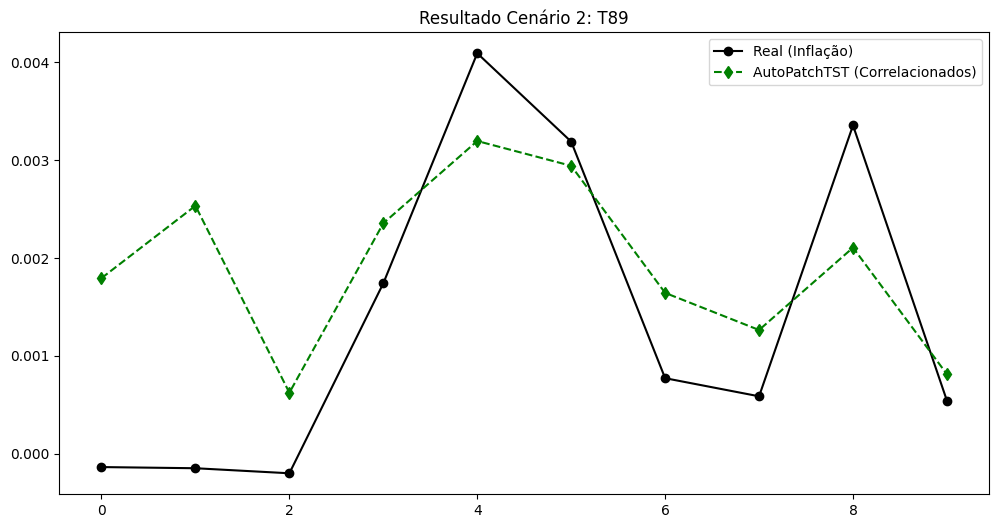

MAE Cenário 2: 0.0010


In [ ]:
preds2 = nf2.predict()
y_pred_c2 = preds2.query(f"unique_id == '{nome_target}'")['AutoPatchTST'].values

y_real = df_diff[nome_target].iloc[715:].values

plt.figure(figsize=(12, 6))
plt.plot(y_real, label='Real (Inflação)', color='black', marker='o')
plt.plot(y_pred_c2, label='AutoPatchTST (Correlacionados)', color='green', linestyle='--', marker='d')
plt.title(f'Resultado Cenário 2: {nome_target}')
plt.legend()
plt.show()
MAE2 = mean_absolute_error(y_real, y_pred_c2)

print(f"MAE Cenário 2: {mean_absolute_error(y_real, y_pred_c2):.4f}")

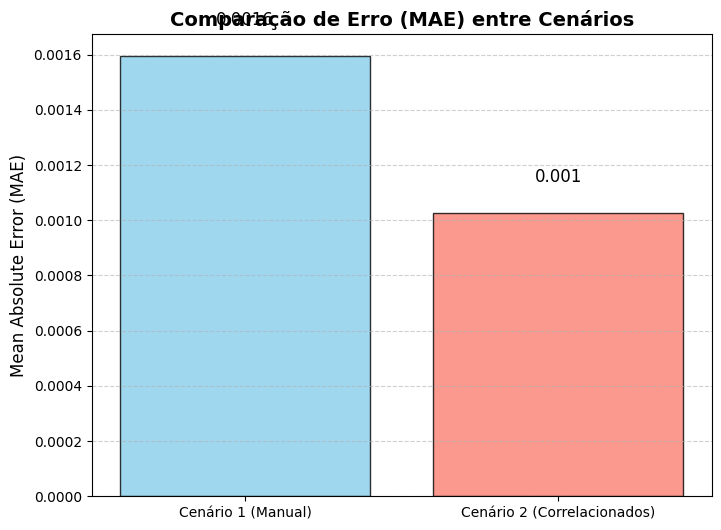

In [ ]:
import matplotlib.pyplot as plt

labels = ['Cenário 1 (Manual)', 'Cenário 2 (Correlacionados)']
valores_mae = [MAE1, MAE2]
cores = ['skyblue', 'salmon']

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, valores_mae, color=cores, edgecolor='black', alpha=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0001, round(yval, 4), ha='center', va='bottom', fontsize=12)

plt.title('Comparação de Erro (MAE) entre Cenários', fontsize=14, fontweight='bold')
plt.ylabel('Mean Absolute Error (MAE)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [ ]:
# cálculo das métricas MAE, MSE, SMAPE para cada resultado
metrics_a = evaluate_model(y_real, y_pred_c1)
metrics_b = evaluate_model(y_real, y_pred_c2)

# valores das métricas de avaliação para cada um dos modelos
print(f'ANÁLISE DO MODELO ALTERADO')
print(f'5 variáveis selecionadas = {metrics_a}')
print(f'5 variáveis correlacionadas = {metrics_b}')

ANÁLISE DO MODELO ALTERADO
5 variáveis selecionadas = {'MAE': np.float64(0.0015942339040567633), 'RMSE': np.float64(0.0017911694715630252), 'SMAPE': np.float64(1.2112574098203936)}
5 variáveis correlacionadas = {'MAE': np.float64(0.0010249510372387527), 'RMSE': np.float64(0.001251225762917612), 'SMAPE': np.float64(0.8932707643981036)}


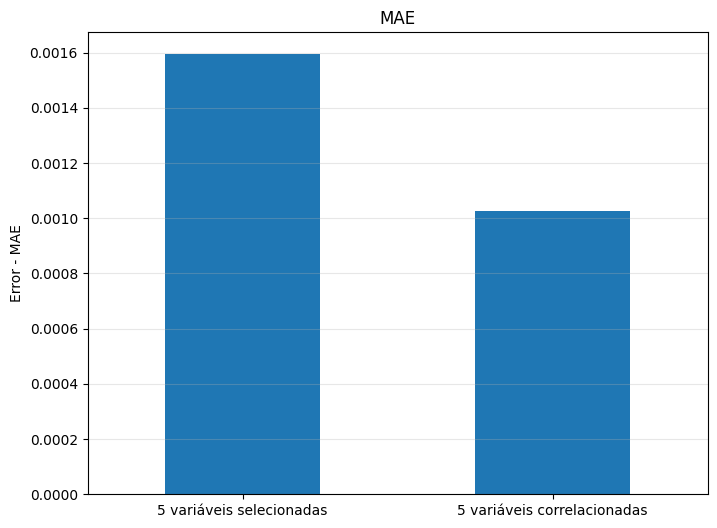

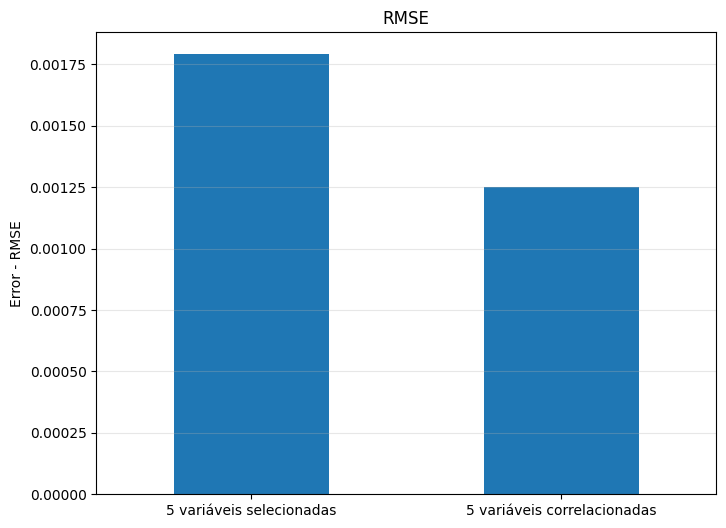

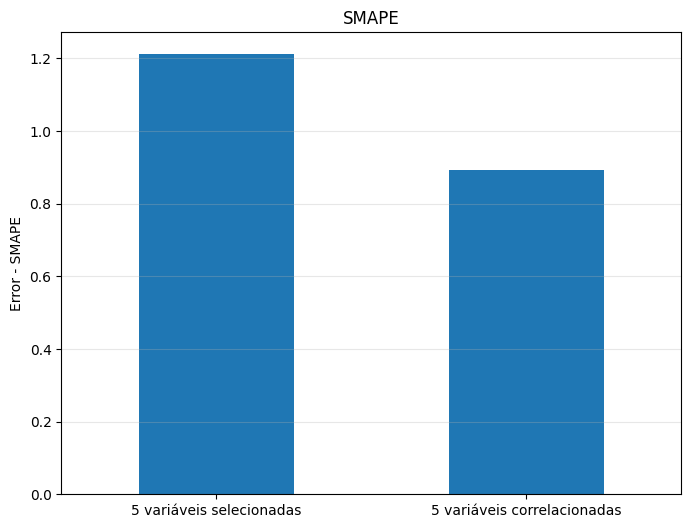

In [ ]:
df_metrics = pd.DataFrame({
    '5 variáveis selecionadas': metrics_a,
    '5 variáveis correlacionadas': metrics_b,
})

for metric in df_metrics.index:
    df_metrics.loc[metric].plot(kind='bar', figsize=(8, 6))
    plt.title(metric)
    plt.ylabel(f'Error - {metric}')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

Agora, analisando o resultado do modelo original:

In [ ]:
def modelo_original() :
  modelo = PatchTST (
      # tamanho do forecasting horizon
      h = 10,
      # tamanho da janela a ser observada
      input_size = 96,
      # 3 camadas no encoder do modelo
      encoder_layers = 3,
      # uso de RevIN para normalização dos dados
      revin = True,
      # taxa do dropout
      dropout = 0.2,
      # tamanho do patch
      patch_len = 16,
      # tamanho do stride, passo entre os patches
      stride = 16,
      batch_size = 32,
      max_steps = 2000,
      learning_rate = 0.0001,
      loss = MAE(),
      valid_loss = MAE(),
  )
  return modelo

In [ ]:
# treinamento do modelo original com as 5 VARIÁVEIS ESCOLHIDAS
modelO1= modelo_original()

nfOg1 = NeuralForecast(models = [modelO1], freq = 'ME')
nfOg1.fit(df = df_c1_train, val_size =10)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ train │     0 │
│ 1 │ valid_loss   │ MAE               │      0 │ train │     0 │
│ 2 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 3 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 4 │ model        │ PatchTST_backbone │  409 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 409 K                                                                                            
Non-trainable params: 3                                                                                            
Total params: 409 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 91                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=2000` reached.


In [ ]:
# treinamento do modelo com as 5 VARIÁVEIS DITAS COMO MAIS CORRELACIONADAS
modelO2= modelo_original()

nfOg2 = NeuralForecast(models = [modelO2], freq = 'ME')
nfOg2.fit(df = df_c2_train, val_size =10)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ train │     0 │
│ 1 │ valid_loss   │ MAE               │      0 │ train │     0 │
│ 2 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 3 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 4 │ model        │ PatchTST_backbone │  409 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 409 K                                                                                            
Non-trainable params: 3                                                                                            
Total params: 409 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 91                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=2000` reached.


In [ ]:
# treinamento do modelo com as 70 PRIMEIRAS VARIÁVEIS DO DATASET
modelO3 = modelo_original()

nfOg3 = NeuralForecast(models = [modelO3], freq = 'ME')
nfOg3.fit(df = df_c3_train, val_size =10)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ train │     0 │
│ 1 │ valid_loss   │ MAE               │      0 │ train │     0 │
│ 2 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 3 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 4 │ model        │ PatchTST_backbone │  409 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 409 K                                                                                            
Non-trainable params: 3                                                                                            
Total params: 409 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 91                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=2000` reached.


In [ ]:
# valores das predições do modelo original
predOg1 = nfOg1.predict()
predOg2 = nfOg2.predict()
predOg3 = nfOg3.predict()

y_predOg1 = predOg1.query(f"unique_id == '{nome_target}'")['PatchTST'].values
y_predOg2 = predOg2.query(f"unique_id == '{nome_target}'")['PatchTST'].values
y_predOg3 = predOg3.query(f"unique_id == '{nome_target}'")['PatchTST'].values

# valores reais para teste (horizon = 10)
y_true = df_diff[nome_target].iloc[715:].values

# cálculo das métricas MAE, MSE, SMAPE para cada resultado
metrics_1 = evaluate_model(y_true, y_predOg1)
metrics_2 = evaluate_model(y_true, y_predOg2)
metrics_3 = evaluate_model(y_true, y_predOg3)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [ ]:
# valores das métricas de avaliação para cada um dos modelos
print(f'ANÁLISE DO MODELO ORIGINAL')
print(f'5 variáveis selecionadas = {metrics_1}')
print(f'5 variáveis correlacionadas = {metrics_2}')
print(f'70 primeiras variáveis = {metrics_3}')

ANÁLISE DO MODELO ORIGINAL
5 variáveis selecionadas = {'MAE': np.float64(0.0016993170860087781), 'RMSE': np.float64(0.0019374992005869477), 'SMAPE': np.float64(1.1633475743671267)}
5 variáveis correlacionadas = {'MAE': np.float64(0.0013589618215566035), 'RMSE': np.float64(0.0015654706873909061), 'SMAPE': np.float64(1.0764129980669233)}
70 primeiras variáveis = {'MAE': np.float64(0.0014077432407294866), 'RMSE': np.float64(0.0015471387151693669), 'SMAPE': np.float64(1.0962313817636542)}


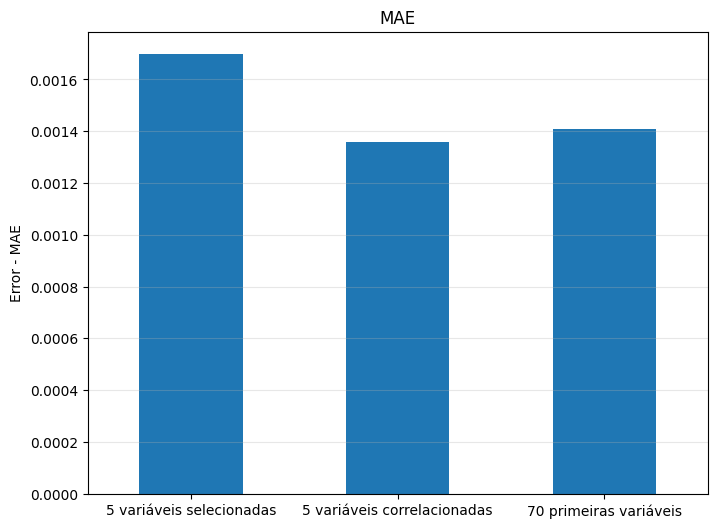

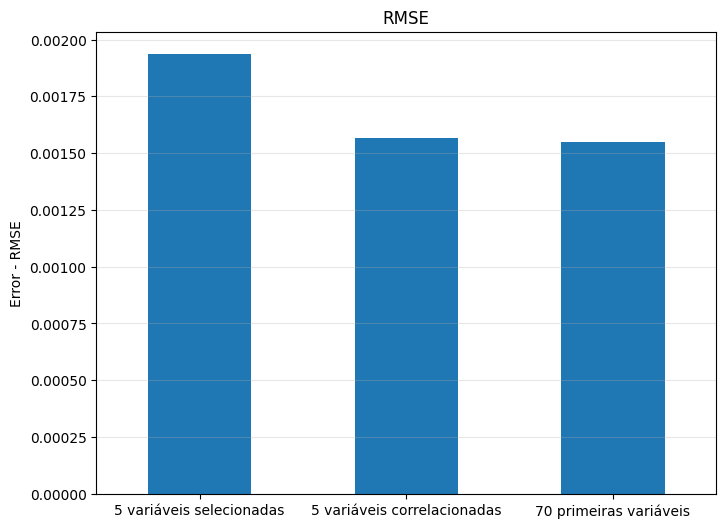

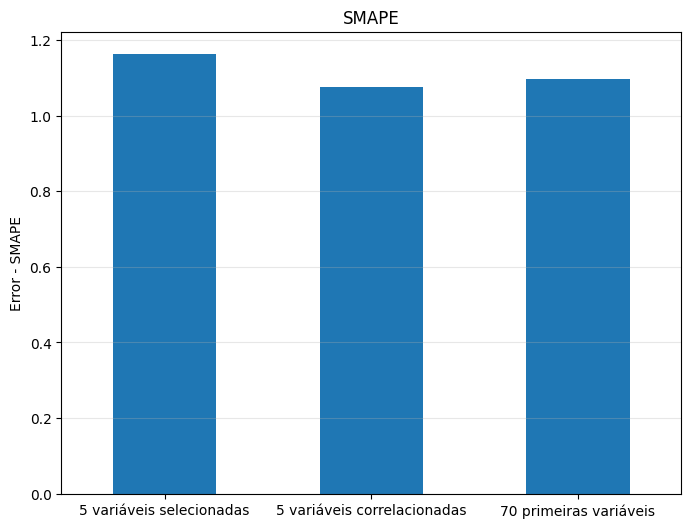

In [ ]:
df_metrics = pd.DataFrame({
    '5 variáveis selecionadas': metrics_1,
    '5 variáveis correlacionadas': metrics_2,
    '70 primeiras variáveis': metrics_3
})

for metric in df_metrics.index:
    df_metrics.loc[metric].plot(kind='bar', figsize=(8, 6))
    plt.title(metric)
    plt.ylabel(f'Error - {metric}')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

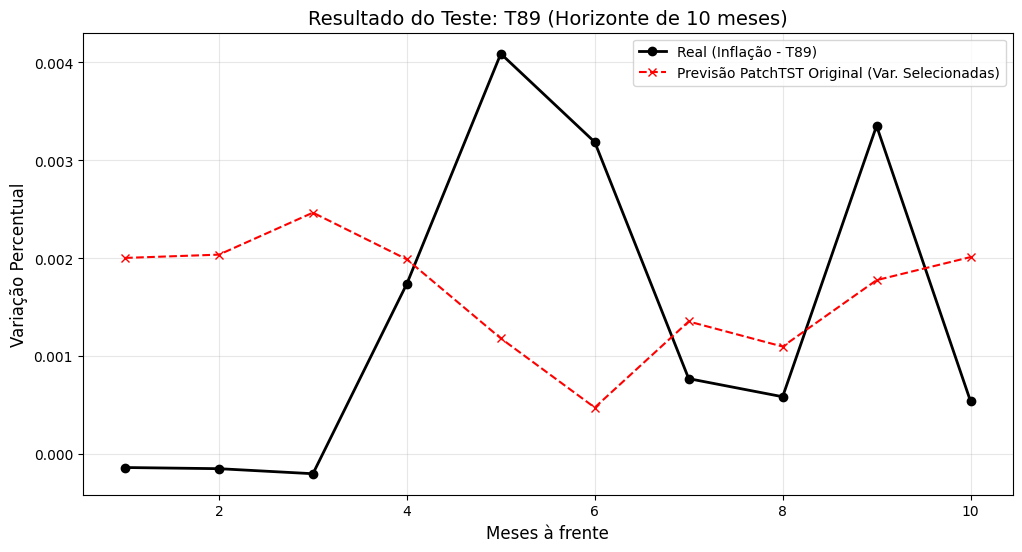

MAE Cenário 1: 0.0017


In [ ]:
# ANÁLISE DA PREVISÃO DO MODELO TREINADO COM AS 5 VARIÁVEIS QUE SELECIONAMOS
plt.figure(figsize=(12, 6))
eixo_x = range(1, horizonte + 1)

plt.plot(eixo_x, y_real, label='Real (Inflação - T89)', color='black', marker='o', linewidth=2)
plt.plot(eixo_x, y_predOg1, label='Previsão PatchTST Original (Var. Selecionadas)', color='red', linestyle='--', marker='x')

plt.title(f'Resultado do Teste: {nome_target} (Horizonte de 10 meses)', fontsize=14)
plt.xlabel('Meses à frente', fontsize=12)
plt.ylabel('Variação Percentual', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"MAE Cenário 1: {mean_absolute_error(y_real, y_predOg1):.4f}")

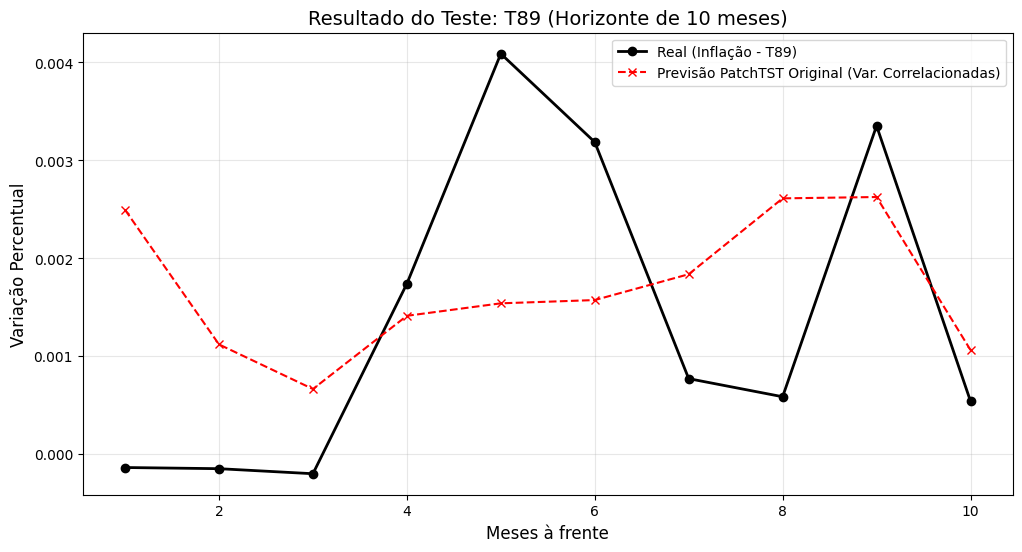

MAE Cenário 2: 0.0014


In [ ]:
# ANÁLISE DA PREVISÃO DO MODELO TREINADO COM AS 5 VARIÁVEIS MAIS CORRELACIONADAS
plt.figure(figsize=(12, 6))
eixo_x = range(1, horizonte + 1)

plt.plot(eixo_x, y_real, label='Real (Inflação - T89)', color='black', marker='o', linewidth=2)
plt.plot(eixo_x, y_predOg2, label='Previsão PatchTST Original (Var. Correlacionadas)', color='red', linestyle='--', marker='x')

plt.title(f'Resultado do Teste: {nome_target} (Horizonte de 10 meses)', fontsize=14)
plt.xlabel('Meses à frente', fontsize=12)
plt.ylabel('Variação Percentual', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"MAE Cenário 2: {mean_absolute_error(y_real, y_predOg2):.4f}")

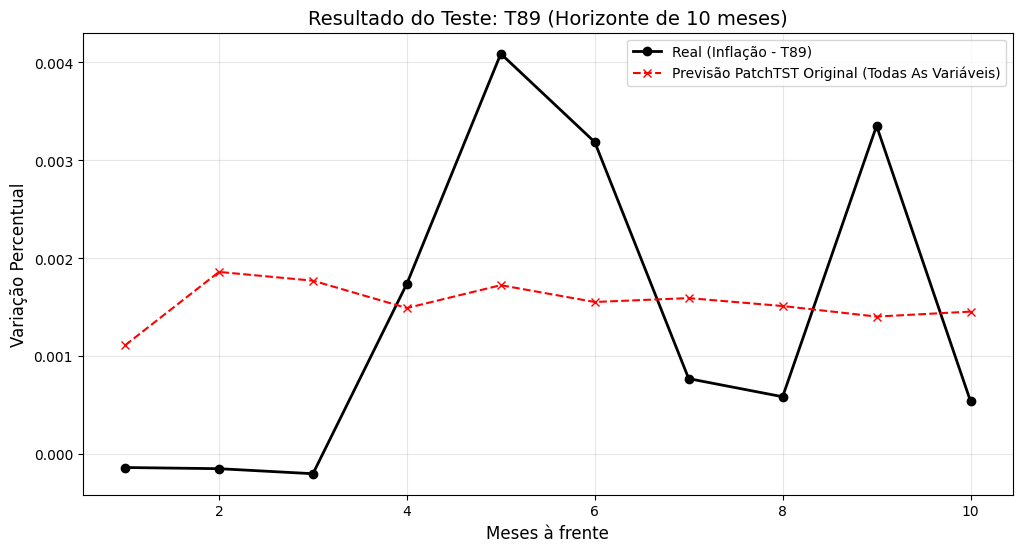

MAE Cenário 3: 0.0014


In [ ]:
# ANÁLISE DA PREVISÃO DO MODELO TREINADO COM AS 70 PRIMEIRAS VARIÁVEIS
plt.figure(figsize=(12, 6))
eixo_x = range(1, horizonte + 1)

plt.plot(eixo_x, y_real, label='Real (Inflação - T89)', color='black', marker='o', linewidth=2)
plt.plot(eixo_x, y_predOg3, label='Previsão PatchTST Original (Todas As Variáveis)', color='red', linestyle='--', marker='x')

plt.title(f'Resultado do Teste: {nome_target} (Horizonte de 10 meses)', fontsize=14)
plt.xlabel('Meses à frente', fontsize=12)
plt.ylabel('Variação Percentual', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"MAE Cenário 3: {mean_absolute_error(y_real, y_predOg3):.4f}")

## Comparando os 5 cenários:

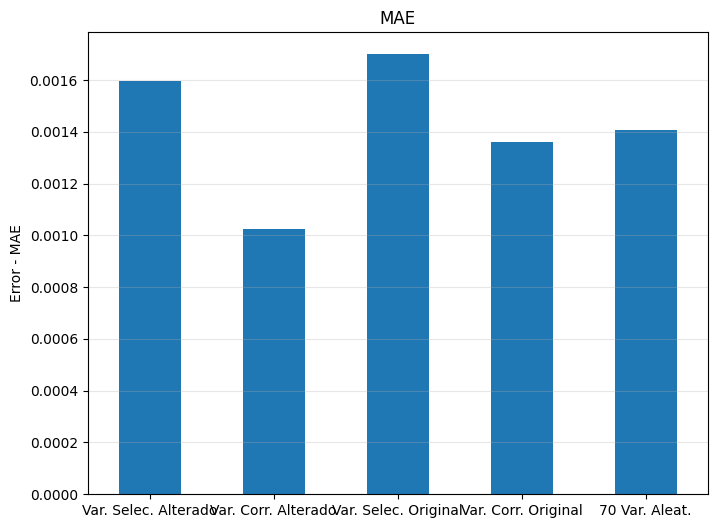

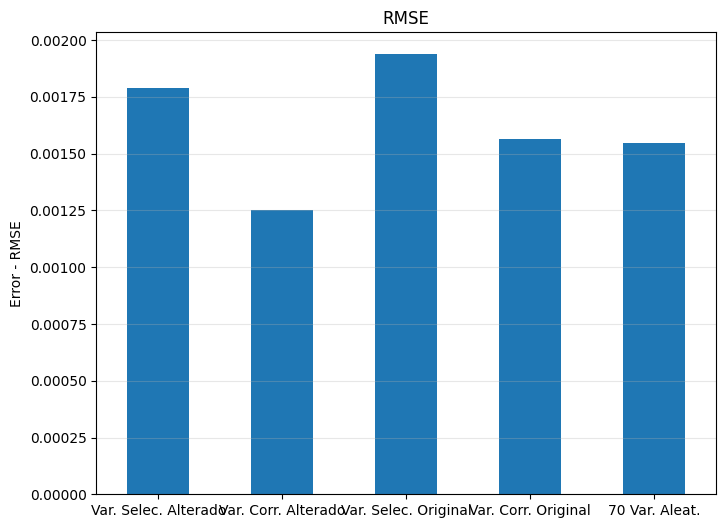

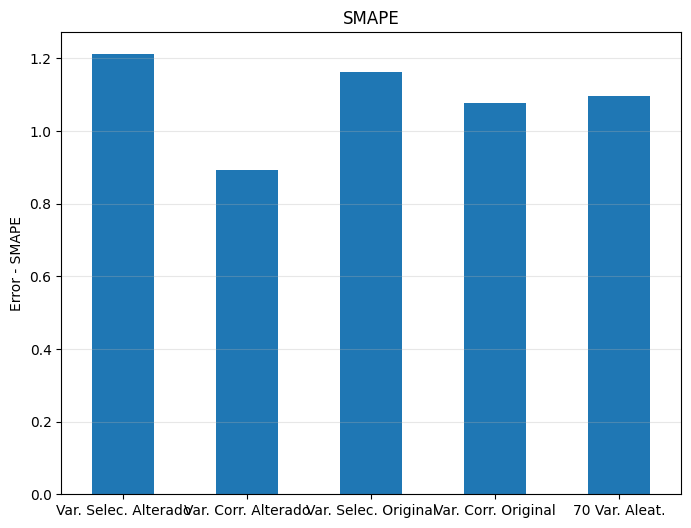

In [ ]:
df_metrics = pd.DataFrame({
    'Var. Selec. Alterado': metrics_a,
    'Var. Corr. Alterado': metrics_b,
    'Var. Selec. Original': metrics_1,
    'Var. Corr. Original': metrics_2,
    '70 Var. Aleat.': metrics_3
})

for metric in df_metrics.index:
    df_metrics.loc[metric].plot(kind='bar', figsize=(8, 6))
    plt.title(metric)
    plt.ylabel(f'Error - {metric}')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

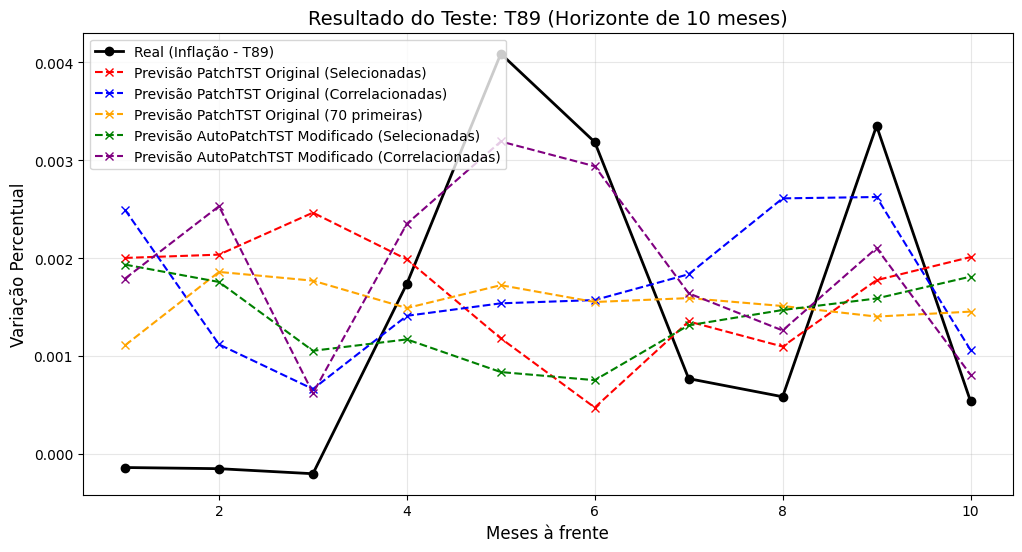

In [ ]:
plt.figure(figsize=(12, 6))
eixo_x = range(1, horizonte + 1)

plt.plot(eixo_x, y_real, label='Real (Inflação - T89)', color='black', marker='o', linewidth=2)
plt.plot(eixo_x, y_predOg1, label='Previsão PatchTST Original (Selecionadas)', color='red', linestyle='--', marker='x')
plt.plot(eixo_x, y_predOg2, label='Previsão PatchTST Original (Correlacionadas)', color='blue', linestyle='--', marker='x')
plt.plot(eixo_x, y_predOg3, label='Previsão PatchTST Original (70 primeiras)', color='orange', linestyle='--', marker='x')
plt.plot(eixo_x, y_pred_c1, label='Previsão AutoPatchTST Modificado (Selecionadas)', color='green', linestyle='--', marker='x')
plt.plot(eixo_x, y_pred_c2, label='Previsão AutoPatchTST Modificado (Correlacionadas)', color='purple', linestyle='--', marker='x')

plt.title(f'Resultado do Teste: {nome_target} (Horizonte de 10 meses)', fontsize=14)
plt.xlabel('Meses à frente', fontsize=12)
plt.ylabel('Variação Percentual', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Considerações finais:

Podemos observar que o modelo que obteve maior sucesso foi o PatchTST alterado treinado com as 5 variáveis mais correlacionadas à variável alvo. Este obteve as menores perdas em todas as métricas de avaliação utilizadas, além de ter tido a curva que mais se assemelha à real no gráfico que compara as previsões, onde observamos que esta acompanha o crescimento e o decrescimento da curva do valores reais.

Os piores resultados observados foram os obtidos com ambos os modelos original e alterado treinados com as 5 variáveis por nós selecionadas, com as maiores losses e as curvas mais distantes do valor verdadeiro.